# VAR — Vetor Autorregressivo entre Indicadores Macroeconômicos

O [projeto ARIMA](projeto_ipca_selic/ipca_arima.ipynb) deste módulo modela o IPCA
**isoladamente** — cada valor futuro é previsto só a partir do próprio passado da série.
Mas IPCA, Selic e câmbio se afetam mutuamente na economia real: o Banco Central reage à
inflação ajustando a Selic, e o câmbio responde a mudanças de juros. Um modelo VAR
(*Vector AutoRegression*) modela **várias séries de uma vez**, sem impor de antemão qual
causa qual — deixando os dados mostrarem essas relações.

Pré-requisito: [Módulo 08 — Econometria II](../08_Econometria_II)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bcb import sgs
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR

plt.rcParams.update({'font.size': 12})

## 1. Coletando os dados

Três séries reais via API do SGS/Banco Central: **IPCA** (inflação mensal, %), **Selic**
(taxa de juros acumulada no mês, %) e **câmbio** (dólar PTAX, diário — convertido para
retorno mensal em log).

In [2]:
dados = sgs.get({'ipca': 433, 'selic': 4390}, start='2017-01-01')
cambio = sgs.get({'cambio': 1}, start='2017-01-01')
cambio_mensal = cambio.resample('MS').last()

df = dados.join(cambio_mensal, how='inner').dropna()
df['cambio_retorno'] = np.log(df['cambio']).diff() * 100
df['selic_variacao'] = df['selic'].diff()   # ver seção 2 -- por que diferenciamos a Selic
df = df.dropna()

print(f"{len(df)} observações mensais, de {df.index.min():%Y-%m} a {df.index.max():%Y-%m}")
df[['ipca', 'selic', 'cambio_retorno', 'selic_variacao']].tail()

113 observações mensais, de 2017-02 a 2026-06


,ipca,selic,cambio_retorno,selic_variacao
Date,,,,
2026-02-01,0.70,1.00,-1.553078,-0.16
2026-03-01,0.88,1.21,1.348283,0.21
2026-04-01,0.67,1.09,-4.522714,-0.12
2026-05-01,0.58,1.07,1.359834,-0.02
2026-06-01,0.16,1.12,2.339482,0.05


## 2. Checando estacionariedade -- pré-requisito do VAR

Um VAR exige que **todas** as séries sejam estacionárias (senão os coeficientes e os
testes de significância ficam inválidos) -- o mesmo teste ADF do
[projeto ARIMA](projeto_ipca_selic/ipca_arima.ipynb) deste módulo, aplicado a cada
série candidata.

In [3]:
def testar_estacionariedade(serie, nome):
    resultado = adfuller(serie)
    status = "estacionária" if resultado[1] < 0.05 else "NÃO estacionária"
    print(f"{nome:<15} ADF={resultado[0]:.3f}   p-valor={resultado[1]:.4f}   -> {status}")

testar_estacionariedade(df['ipca'], 'IPCA')
testar_estacionariedade(df['selic'], 'Selic (nível)')
testar_estacionariedade(df['cambio_retorno'], 'Câmbio (retorno)')

IPCA            ADF=-6.279   p-valor=0.0000   -> estacionária
Selic (nível)   ADF=-0.997   p-valor=0.7544   -> NÃO estacionária
Câmbio (retorno) ADF=-10.624   p-valor=0.0000   -> estacionária


A Selic em **nível** não passa no teste (comportamento esperado: juros seguem
ciclos longos de alta/baixa, sem reverter à média rapidamente). IPCA e o retorno cambial
já são estacionários. Solução padrão: usar a **primeira diferença** da Selic (a variação
mês a mês da taxa, não o nível) -- é o que `selic_variacao` já fez na coleta.

In [4]:
testar_estacionariedade(df['selic_variacao'], 'Selic (variação)')

Selic (variação) ADF=-3.427   p-valor=0.0101   -> estacionária


## 3. Escolha da ordem de defasagens

Assim como o ARIMA escolhe $(p, d, q)$ por critério de informação, o VAR escolhe quantas
defasagens ($p$) incluir de cada série nas equações das outras. `select_order` calcula
AIC, BIC, FPE e HQIC para cada candidato.

In [5]:
variaveis = df[['ipca', 'selic_variacao', 'cambio_retorno']]
variaveis.columns = ['ipca', 'd_selic', 'cambio_ret']

modelo_var = VAR(variaveis)
selecao = modelo_var.select_order(maxlags=6)
print(selecao.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -3.823      -3.748     0.02187      -3.792
1      -4.289     -3.989*     0.01372      -4.167
2      -4.249      -3.724     0.01429      -4.036
3     -4.557*      -3.808    0.01051*     -4.254*
4      -4.550      -3.576     0.01061      -4.155
5      -4.496      -3.297     0.01123      -4.010
6      -4.396      -2.972     0.01247      -3.819
-------------------------------------------------


Os critérios não concordam perfeitamente (comum na prática) — BIC, mais
conservador, prefere só 1 defasagem; AIC prefere 4. Seguimos com **2 defasagens**, um
meio-termo razoável que mantém graus de liberdade suficientes com pouco mais de 100
observações mensais.

## 4. Estimando o VAR

In [6]:
resultado_var = modelo_var.fit(2)
print(resultado_var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 06, Aug, 2026
Time:                     03:25:35
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -3.76548
Nobs:                     111.000    HQIC:                  -4.07014
Log likelihood:          -214.072    FPE:                  0.0138761
AIC:                     -4.27809    Det(Omega_mle):       0.0115502
--------------------------------------------------------------------
Results for equation ipca
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.217986         0.054974            3.965           0.000
L1.ipca               0.417367         0.097691            4.272           0.000
L1.d_selic           -0.141746         0.420842           -0.

## 5. Causalidade de Granger

"$X$ Granger-causa $Y$" significa: valores passados de $X$ ajudam a prever $Y$ **além**
do que o passado do próprio $Y$ já prevê. Não é causalidade no sentido filosófico forte —
é um teste estatístico de precedência temporal preditiva.

In [7]:
# test_causality(caused, [causing]) -- o 1º argumento é a variável CAUSADA, o 2º a CAUSADORA
pares = [
    ('ipca', 'd_selic', 'IPCA -> variação da Selic'),
    ('d_selic', 'ipca', 'variação da Selic -> IPCA'),
    ('ipca', 'cambio_ret', 'IPCA -> câmbio'),
    ('cambio_ret', 'd_selic', 'câmbio -> variação da Selic'),
]

for causando, causada, rotulo in pares:
    teste = resultado_var.test_causality(causada, [causando], kind='f')
    veredito = "REJEITA H0 (há causalidade de Granger)" if teste.pvalue < 0.05 else "não rejeita H0"
    print(f"{rotulo:<28} p-valor={teste.pvalue:.4f}   {veredito}")

IPCA -> variação da Selic    p-valor=0.0002   REJEITA H0 (há causalidade de Granger)
variação da Selic -> IPCA    p-valor=0.1803   não rejeita H0
IPCA -> câmbio               p-valor=0.6704   não rejeita H0
câmbio -> variação da Selic  p-valor=0.3484   não rejeita H0


O único link que se confirma nessa amostra é **IPCA → variação da Selic** — plausível
e economicamente esperado: o Banco Central historicamente reage à inflação ajustando a
taxa básica de juros (uma versão simplificada de uma regra de Taylor). As demais direções
(Selic → IPCA, câmbio → IPCA, Selic → câmbio) não são estatisticamente significativas
nesta especificação — o que não significa ausência de qualquer relação econômica, só que
este modelo simples e esta amostra não capturam evidência forte dela.

## 6. Função de resposta a impulso (IRF)

Mostra como um choque de um desvio-padrão em uma variável se propaga pelas outras ao
longo do tempo — a forma mais direta de visualizar a dinâmica capturada pelo VAR. Dado o
resultado da seção anterior, vale acompanhar em especial como um choque em IPCA se
propaga para a variação da Selic.

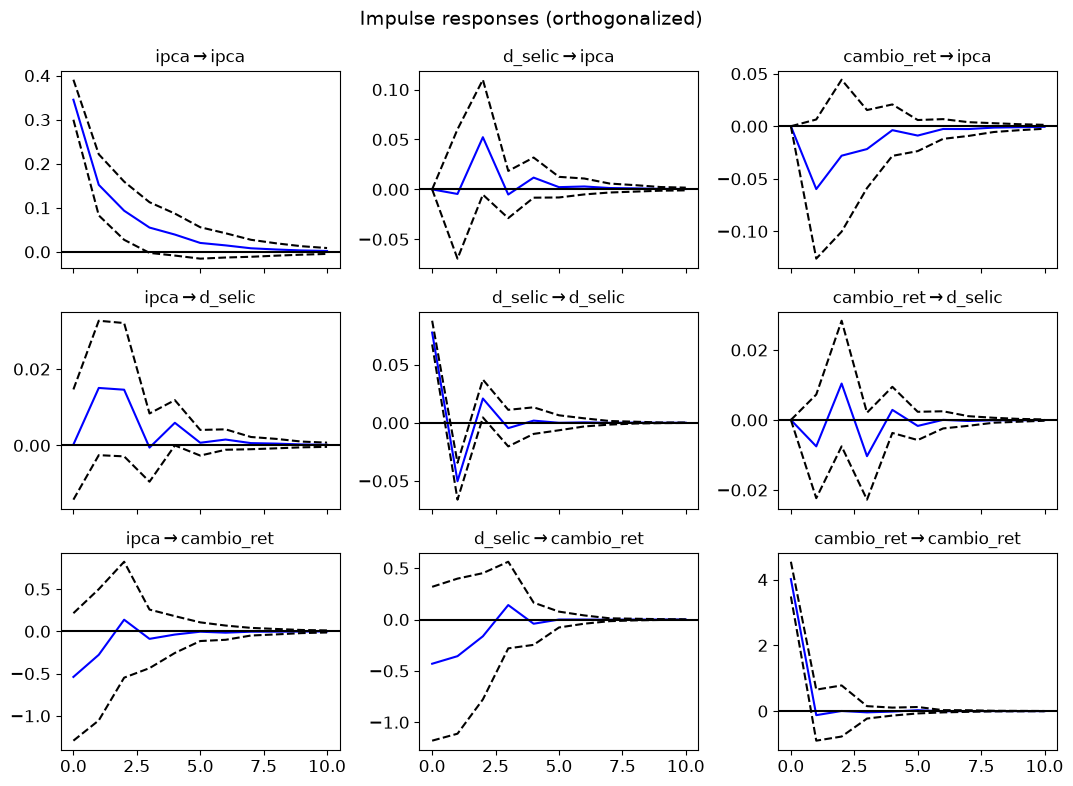

In [8]:
irf = resultado_var.irf(10)
fig = irf.plot(orth=True, figsize=(11, 8))
plt.tight_layout()
plt.savefig('img_var_irf.png', dpi=110)
plt.show()

## 7. Previsão com VAR

Assim como o ARIMA projeta a série adiante, o VAR projeta **todas** as séries do sistema
simultaneamente, cada uma usando informação das outras.

In [9]:
ultimas_obs = variaveis.values[-resultado_var.k_ar:]
previsao = resultado_var.forecast(ultimas_obs, steps=6)

datas_futuras = pd.date_range(df.index[-1], periods=7, freq='MS')[1:]
df_previsao = pd.DataFrame(previsao, index=datas_futuras, columns=variaveis.columns)
print(df_previsao)

                ipca   d_selic  cambio_ret
2026-07-01  0.275512 -0.031525    0.615450
2026-08-01  0.363804 -0.001543    0.163668
2026-09-01  0.371503 -0.001385    0.552014
2026-10-01  0.392370 -0.002528    0.459404
2026-11-01  0.402729  0.000393    0.447897
2026-12-01  0.407972  0.000051    0.453129


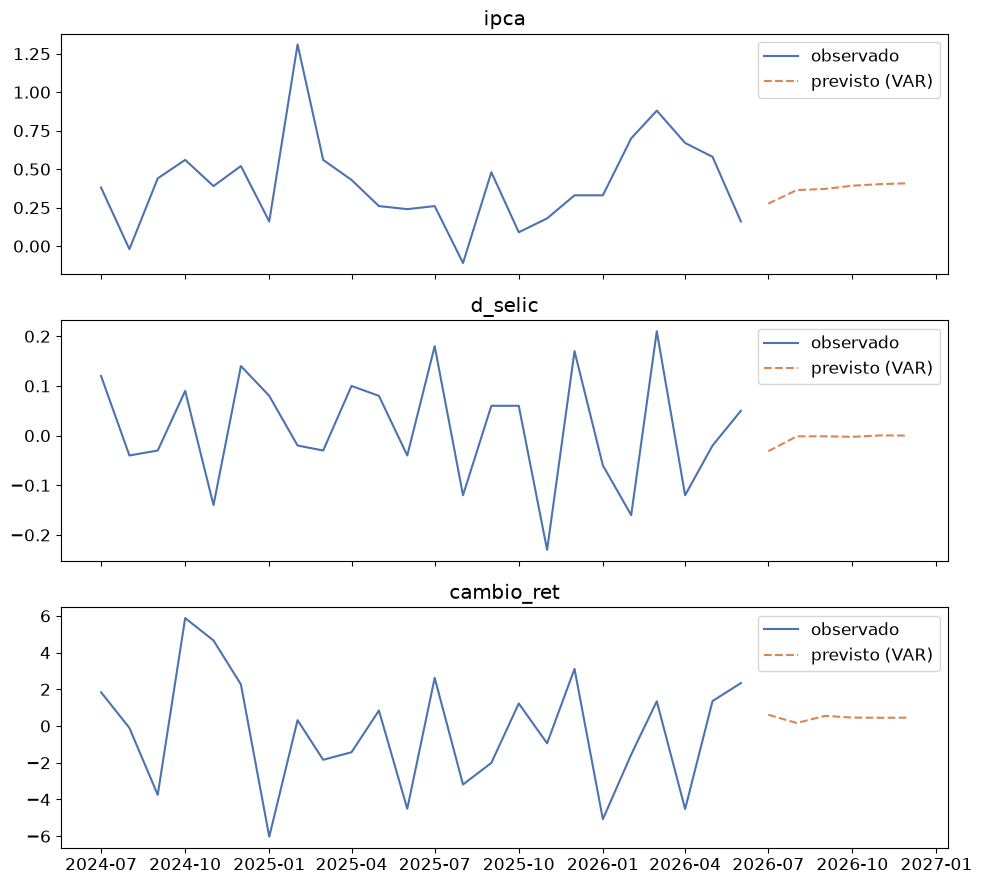

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, col in zip(axes, variaveis.columns):
    ax.plot(variaveis.index[-24:], variaveis[col].iloc[-24:], label='observado', color='#4C72B0')
    ax.plot(df_previsao.index, df_previsao[col], label='previsto (VAR)', color='#DD8452', linestyle='--')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.savefig('img_var_previsao.png', dpi=110)
plt.show()

## 8. Exercícios de fixação

1. Refaça a seleção de ordem (`select_order`) usando `maxlags=12`. O critério AIC ainda
   escolhe a mesma defasagem?
2. Teste a causalidade de Granger de `cambio_ret` sobre `d_selic` (variação cambial
   antecipa mudanças de juros?). O resultado bate com a intuição de que o Banco Central
   também reage à taxa de câmbio?

In [11]:
# 1.
selecao_12 = modelo_var.select_order(maxlags=12)
print("1) Ordem sugerida por AIC (maxlags=12):", selecao_12.aic)

# 2.
teste_cambio_selic = resultado_var.test_causality('d_selic', ['cambio_ret'], kind='f')
print(f"\n2) câmbio -> variação da Selic: p-valor={teste_cambio_selic.pvalue:.4f}")
print("   Rejeita H0 -> há evidência de causalidade de Granger."
      if teste_cambio_selic.pvalue < 0.05 else
      "   Não rejeita H0 -> nesta amostra e especificação, não há evidência estatística")
print("   forte desse link, mesmo sendo economicamente plausível.")

1) Ordem sugerida por AIC (maxlags=12): 3

2) câmbio -> variação da Selic: p-valor=0.3484
   Não rejeita H0 -> nesta amostra e especificação, não há evidência estatística
   forte desse link, mesmo sendo economicamente plausível.


## Encerramento

Com VAR, causalidade de Granger, IRF e previsão multivariada, o Módulo 09 ganha a
extensão que seu próprio README já apontava como próximo passo natural do projeto ARIMA.
A [ponte com Econometria II](../08_Econometria_II) fica completa: dados em painel tratam
múltiplas unidades ao longo do tempo; VAR trata múltiplas séries que se afetam
mutuamente ao longo do tempo.

## Bibliografia
- ENDERS, Walter. *Applied Econometric Time Series*. 4. ed. Wiley, 2014.
- LÜTKEPOHL, Helmut. *New Introduction to Multiple Time Series Analysis*. Springer, 2005.
- SIMS, Christopher A. (1980). "Macroeconomics and Reality". *Econometrica*, 48(1).
- HAMILTON, James D. *Time Series Analysis*. Princeton University Press, 1994.